
# Week 6: Urban Flood Depth Estimation Pipeline

## Overview
This notebook presents the **end-to-end urban flood depth estimation workflow**. Building on Week 5, where vehicles were detected and cropped from a street-level flood image, this week moves into the next stage: estimating **flood severity around each detected vehicle** and aggregating those results into a scene-level decision.

The workflow combines:
- vehicle detection
- context-aware cropping
- optional image enhancement for small crops
- flood level classification
- confidence-weighted aggregation
- annotated output generation

This notebook is designed as a **teaching-first approximation** of the full research workflow, while staying runnable in a standard GitHub course setting.

## Learning Objectives
- Understand the stages of a vehicle-centered urban flood depth estimation pipeline
- Review how crop quality affects downstream prediction
- Simulate per-crop flood severity classification
- Understand why small crops may require enhancement
- Aggregate multiple crop-level predictions into a final scene-level flood estimate
- Generate annotated outputs and structured prediction summaries

## Expected Outcome
By the end of this notebook, you should be able to explain and run a simplified end-to-end flood-depth estimation pipeline for a street-level urban image.



## Notebook Structure

1. Environment setup  
2. Why full-pipeline reasoning matters  
3. Pipeline overview  
4. Load or create a street-level image  
5. Define vehicle detections  
6. Expand crops with context  
7. Simulate crop enhancement logic  
8. Simulate flood-level classification  
9. Aggregate crop predictions  
10. Generate annotated outputs  
11. Mini exercise  
12. Weekly assignment  

> This notebook is course-friendly and uses synthetic examples so students can understand the pipeline logic before using the full research notebooks.


In [1]:

# Week 6 setup: imports and environment check

import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

print("Python version:", sys.version.split()[0])
print("Working directory:", os.getcwd())


Python version: 3.12.12
Working directory: /content


In [2]:

# Create output folder for this week

BASE_DIR = Path.cwd()
OUTPUT_DIR = BASE_DIR / "outputs" / "week06"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Output directory ready:", OUTPUT_DIR)


Output directory ready: /content/outputs/week06



## Why Full-Pipeline Reasoning Matters

A single vehicle crop is useful, but a real urban scene often contains multiple vehicles with:
- different sizes
- different visibility conditions
- different amounts of surrounding water
- different classification confidence levels

That means the final scene-level decision should not depend on only one crop.  
Instead, the workflow should:
1. analyze each detected region
2. estimate a flood level for each crop
3. combine those predictions into a more stable final output

This is why aggregation is a key part of the pipeline.



## Pipeline Overview

The full urban flood depth estimation workflow can be summarized as:

1. Load a street-level flood image  
2. Detect vehicles  
3. Expand crop regions to preserve context  
4. Enhance small crops if needed  
5. Predict flood severity for each crop  
6. Compute crop weights using confidence and area  
7. Aggregate the predictions  
8. Output a final flood level and annotated image  

This is a practical example of **multi-stage computer vision for disaster intelligence**.


In [3]:

# Workflow summary table

pipeline_df = pd.DataFrame({
    "Step": [
        "Load image",
        "Detect vehicles",
        "Expand crop regions",
        "Enhance small crops",
        "Classify flood level",
        "Compute crop weights",
        "Aggregate predictions",
        "Generate annotated output"
    ],
    "Purpose": [
        "Read the urban flood scene",
        "Find vehicle regions of interest",
        "Retain waterline and road-water context",
        "Improve visibility for small detections",
        "Estimate local flood severity",
        "Give stronger detections greater influence",
        "Create a stable scene-level estimate",
        "Support interpretation and communication"
    ]
})

pipeline_df


,Step,Purpose
0,Load image,Read the urban flood scene
1,Detect vehicles,Find vehicle regions of interest
2,Expand crop regions,Retain waterline and road-water context
3,Enhance small crops,Improve visibility for small detections
4,Classify flood level,Estimate local flood severity
5,Compute crop weights,Give stronger detections greater influence
6,Aggregate predictions,Create a stable scene-level estimate
7,Generate annotated output,Support interpretation and communication



## Create a Synthetic Urban Flood Scene

To keep the notebook runnable anywhere, we start with a synthetic image similar to Week 5. The image contains:
- a roadway
- floodwater
- multiple vehicles
- variability in vehicle size

This allows us to demonstrate all pipeline stages in one place.


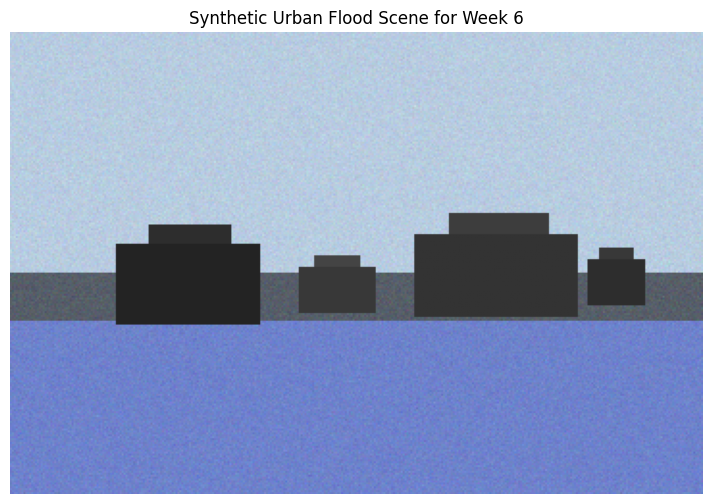

In [4]:

# Create a synthetic urban flood scene

np.random.seed(42)

scene = np.ones((240, 360, 3))
scene[..., 0] = 0.72
scene[..., 1] = 0.80
scene[..., 2] = 0.88

# Road
scene[125:240, :, 0] = 0.34
scene[125:240, :, 1] = 0.37
scene[125:240, :, 2] = 0.41

# Floodwater
scene[150:240, :, 0] = 0.43
scene[150:240, :, 1] = 0.51
scene[150:240, :, 2] = 0.80

# Add light texture
scene += 0.025 * np.random.randn(*scene.shape)
scene = np.clip(scene, 0, 1)

# Vehicle 1
scene[110:152, 55:130, :] = 0.14
scene[100:110, 72:115, :] = 0.18

# Vehicle 2
scene[105:148, 210:295, :] = 0.20
scene[94:105, 228:280, :] = 0.24

# Small vehicle 3
scene[122:146, 150:190, :] = 0.22
scene[116:122, 158:182, :] = 0.27

# Small vehicle 4
scene[118:142, 300:330, :] = 0.18
scene[112:118, 306:324, :] = 0.22

plt.figure(figsize=(10, 6))
plt.imshow(scene)
plt.title("Synthetic Urban Flood Scene for Week 6")
plt.axis("off")
plt.show()



## Simulated Detection Results

In the full workflow, these would come from an object detector such as YOLO-World.  
Here we define detector-like outputs directly.


In [5]:

# Simulated detection results: [x1, y1, x2, y2, confidence, class_name]

detections = [
    [55, 100, 130, 152, 0.95, "vehicle"],
    [210, 94, 295, 148, 0.91, "vehicle"],
    [150, 116, 190, 146, 0.84, "vehicle"],
    [300, 112, 330, 142, 0.78, "vehicle"]
]

detections_df = pd.DataFrame(
    detections, columns=["x1", "y1", "x2", "y2", "confidence", "class_name"]
)
detections_df


,x1,y1,x2,y2,confidence,class_name
0,55,100,130,152,0.95,vehicle
1,210,94,295,148,0.91,vehicle
2,150,116,190,146,0.84,vehicle
3,300,112,330,142,0.78,vehicle


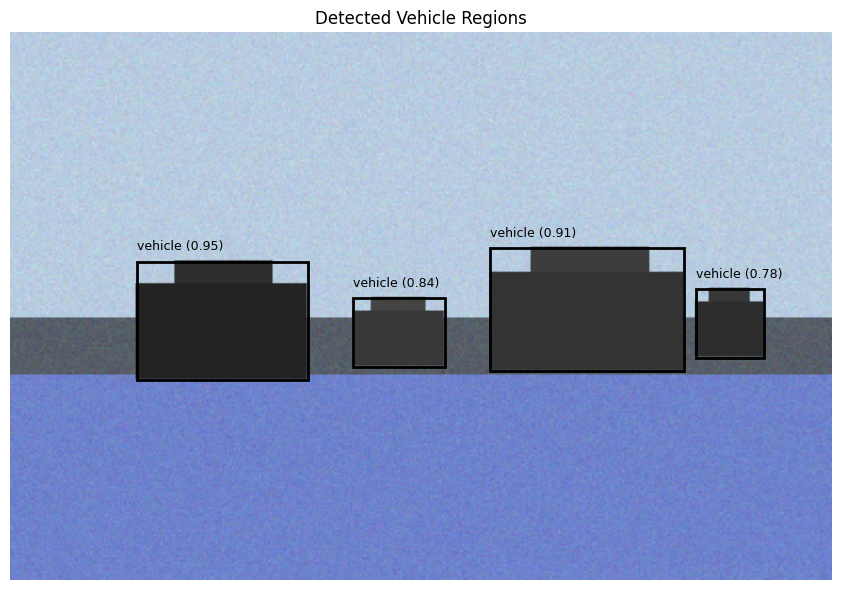

In [6]:

# Visualize detections

fig, ax = plt.subplots(figsize=(10, 6))
ax.imshow(scene)

for det in detections:
    x1, y1, x2, y2, conf, cls = det
    ax.add_patch(Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, linewidth=2))
    ax.text(x1, max(y1 - 5, 5), f"{cls} ({conf:.2f})", fontsize=9)

ax.set_title("Detected Vehicle Regions")
ax.axis("off")
plt.tight_layout()
plt.show()



## Expand Crops to Preserve Water Context

The next step is to expand each detection box so the downstream classifier can observe:
- the local waterline
- pooled water texture
- reflections
- road-water interaction near the vehicle


In [7]:

# Helper to expand a detection box

def expand_box(box, image_shape, scale=1.8):
    x1, y1, x2, y2 = box
    h, w = image_shape[:2]

    cx = (x1 + x2) / 2
    cy = (y1 + y2) / 2
    bw = x2 - x1
    bh = y2 - y1

    new_w = bw * scale
    new_h = bh * scale

    nx1 = int(max(0, cx - new_w / 2))
    ny1 = int(max(0, cy - new_h / 2))
    nx2 = int(min(w, cx + new_w / 2))
    ny2 = int(min(h, cy + new_h / 2))

    return [nx1, ny1, nx2, ny2]

expanded_boxes = [expand_box(det[:4], scene.shape, scale=1.8) for det in detections]
expanded_boxes


[[25, 79, 160, 172],
 [176, 72, 329, 169],
 [134, 104, 206, 158],
 [288, 100, 342, 154]]

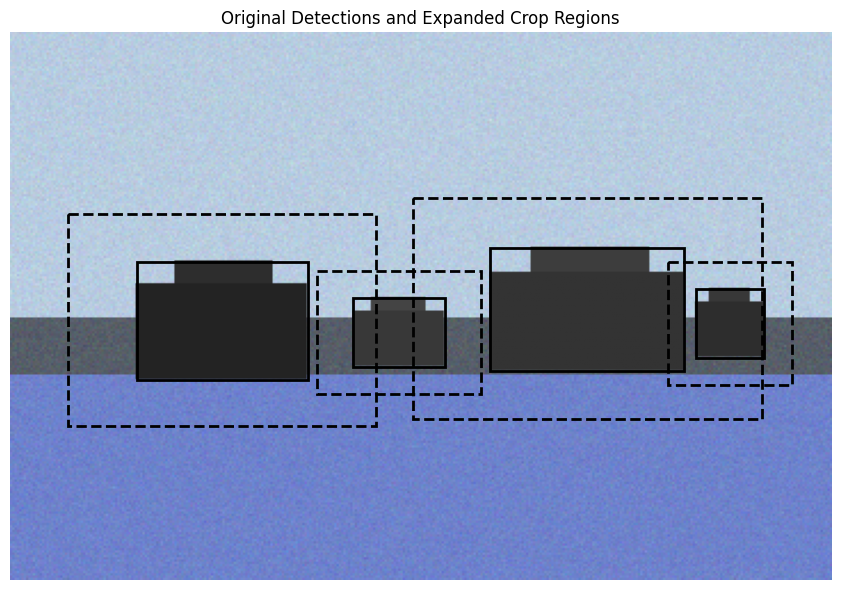

In [8]:

# Visualize original and expanded boxes

fig, ax = plt.subplots(figsize=(10, 6))
ax.imshow(scene)

for det, exp_box in zip(detections, expanded_boxes):
    x1, y1, x2, y2, conf, cls = det
    ex1, ey1, ex2, ey2 = exp_box

    ax.add_patch(Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, linewidth=2))
    ax.add_patch(Rectangle((ex1, ey1), ex2 - ex1, ey2 - ey1, fill=False, linewidth=2, linestyle="--"))

ax.set_title("Original Detections and Expanded Crop Regions")
ax.axis("off")
plt.tight_layout()
plt.show()



## Extract Crop Regions

We now extract the expanded crop regions.  
These crops are the inputs to the next stages of the pipeline.


In [9]:

# Extract expanded crops

expanded_crops = []

for det, exp_box in zip(detections, expanded_boxes):
    ex1, ey1, ex2, ey2 = exp_box
    crop = scene[ey1:ey2, ex1:ex2]
    expanded_crops.append(crop)

print("Number of expanded crops:", len(expanded_crops))
for idx, crop in enumerate(expanded_crops, start=1):
    print(f"Crop {idx} shape:", crop.shape)


Number of expanded crops: 4
Crop 1 shape: (93, 135, 3)
Crop 2 shape: (97, 153, 3)
Crop 3 shape: (54, 72, 3)
Crop 4 shape: (54, 54, 3)


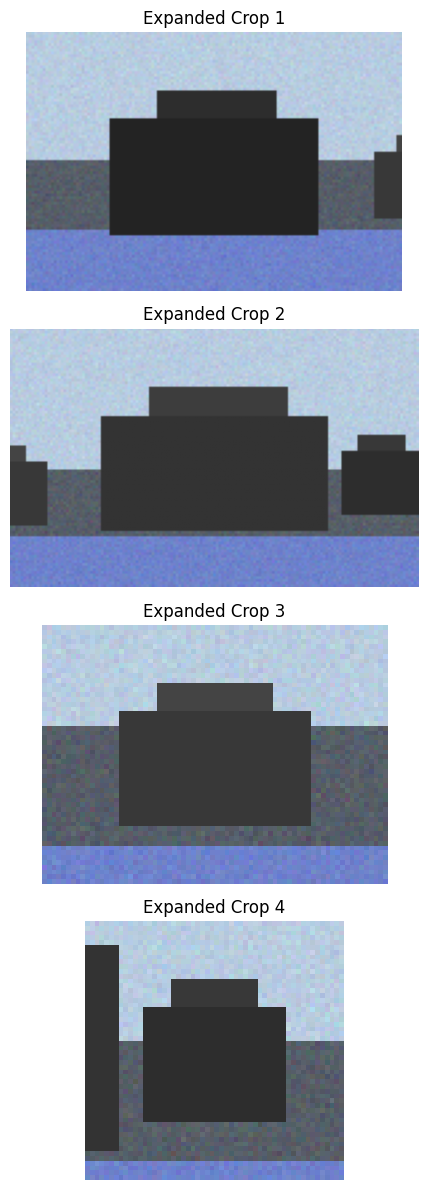

In [10]:

# Visualize the expanded crops

num_crops = len(expanded_crops)
fig, axes = plt.subplots(num_crops, 1, figsize=(6, 3 * num_crops))

if num_crops == 1:
    axes = [axes]

for i, crop in enumerate(expanded_crops):
    axes[i].imshow(crop)
    axes[i].set_title(f"Expanded Crop {i+1}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()



## Small-Crop Enhancement Logic

Small detections often contain limited visual detail. In the full workflow, a super-resolution model such as **EDSR ×4** may be applied when the crop is too small.

For teaching purposes, we simulate this decision rule:
- if crop width or height is below a threshold, mark it as requiring enhancement
- otherwise, keep it as-is


In [11]:

# Decide which crops are considered small and may need enhancement

enhancement_threshold_w = 90
enhancement_threshold_h = 70

enhancement_records = []

for idx, crop in enumerate(expanded_crops, start=1):
    h, w = crop.shape[:2]
    needs_enhancement = (w < enhancement_threshold_w) or (h < enhancement_threshold_h)

    enhancement_records.append({
        "crop_id": idx,
        "width": w,
        "height": h,
        "needs_enhancement": needs_enhancement
    })

enhancement_df = pd.DataFrame(enhancement_records)
enhancement_df


,crop_id,width,height,needs_enhancement
0,1,135,93,False
1,2,153,97,False
2,3,72,54,True
3,4,54,54,True



### Interpretation
In the full research workflow:
- **small crops** may be enhanced using super-resolution
- **larger crops** are sent directly to classification

This helps improve visibility when the detected vehicle region is too limited for reliable prediction.



## Simulate Flood-Level Classification

In the original pipeline, a trained image classifier predicts a flood severity level for each crop.  
For the course notebook, we simulate this step with a simple rule-based proxy using:
- estimated water coverage ratio in the crop
- detection confidence

The predicted levels follow the same idea:
- **Level 0:** safe / no meaningful water
- **Level 1:** water reaching tires
- **Level 2:** water reaching wheel hubs
- **Level 3:** doors/chassis affected
- **Level 4:** severe hazard / high body coverage


In [12]:

# Helper: estimate synthetic water ratio in a crop
# Since our synthetic floodwater is concentrated in the lower part of the scene,
# we estimate water content using the blue channel and crop position.

def estimate_water_ratio(crop):
    # Heuristic: strong blue response with moderate green suggests water-like region
    blue = crop[..., 2]
    green = crop[..., 1]
    red = crop[..., 0]

    water_like = (blue > 0.60) & (green > 0.40) & (red > 0.30)
    return float(water_like.mean())

def ratio_to_level(ratio):
    if ratio < 0.08:
        return 0
    elif ratio < 0.18:
        return 1
    elif ratio < 0.30:
        return 2
    elif ratio < 0.45:
        return 3
    else:
        return 4

classification_records = []

for idx, (det, crop) in enumerate(zip(detections, expanded_crops), start=1):
    x1, y1, x2, y2, conf, cls = det
    ratio = estimate_water_ratio(crop)
    pred_level = ratio_to_level(ratio)

    classification_records.append({
        "crop_id": idx,
        "confidence": round(conf, 2),
        "estimated_water_ratio": round(ratio, 3),
        "predicted_level": pred_level
    })

classification_df = pd.DataFrame(classification_records)
classification_df


,crop_id,confidence,estimated_water_ratio,predicted_level
0,1,0.95,0.592,4
1,2,0.91,0.563,4
2,3,0.84,0.469,4
3,4,0.78,0.380,3


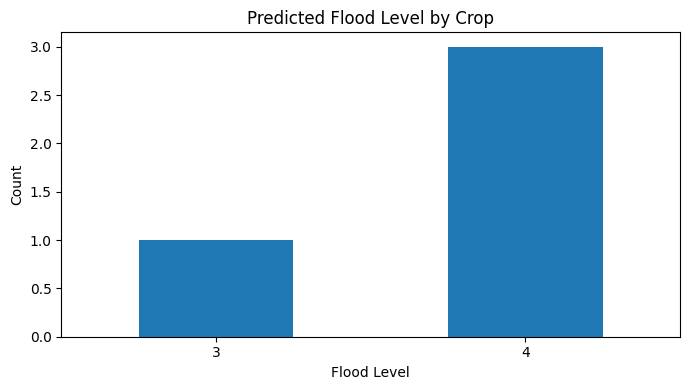

In [13]:

# Show level distribution

level_counts = classification_df["predicted_level"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(7, 4))
level_counts.plot(kind="bar", ax=ax)
ax.set_title("Predicted Flood Level by Crop")
ax.set_xlabel("Flood Level")
ax.set_ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()



## Confidence × Area Weighting

A key idea in the full pipeline is that not all crop predictions should influence the final result equally.

A crop may be more informative if:
- the detection confidence is high
- the crop covers a larger and clearer vehicle region

A simple weighting rule is:

> **weight = confidence × area**

The weighted average of crop predictions produces the final scene-level estimate.


In [14]:

# Compute confidence × area weights and weighted prediction

aggregation_records = []

for idx, (det, exp_box, cls_row) in enumerate(zip(detections, expanded_boxes, classification_records), start=1):
    ex1, ey1, ex2, ey2 = exp_box
    area = (ex2 - ex1) * (ey2 - ey1)
    confidence = cls_row["confidence"]
    predicted_level = cls_row["predicted_level"]
    weight = confidence * area

    aggregation_records.append({
        "crop_id": idx,
        "predicted_level": predicted_level,
        "confidence": confidence,
        "expanded_area": area,
        "weight_conf_x_area": round(weight, 2)
    })

aggregation_df = pd.DataFrame(aggregation_records)
aggregation_df


,crop_id,predicted_level,confidence,expanded_area,weight_conf_x_area
0,1,4,0.95,12555,11927.25
1,2,4,0.91,14841,13505.31
2,3,4,0.84,3888,3265.92
3,4,3,0.78,2916,2274.48


In [15]:

# Compute final weighted flood level

weighted_sum = float((aggregation_df["predicted_level"] * aggregation_df["weight_conf_x_area"]).sum())
total_weight = float(aggregation_df["weight_conf_x_area"].sum())

final_level_continuous = weighted_sum / total_weight if total_weight > 0 else 0.0
final_level_discrete = int(round(final_level_continuous))

summary_df = pd.DataFrame({
    "Metric": ["Weighted sum", "Total weight", "Final continuous level", "Final rounded level"],
    "Value": [round(weighted_sum, 3), round(total_weight, 3), round(final_level_continuous, 3), final_level_discrete]
})

summary_df


,Metric,Value
0,Weighted sum,121617.360
1,Total weight,30972.960
2,Final continuous level,3.927
3,Final rounded level,4.000



### Interpretation
- The **continuous level** preserves more information from all crops.
- The **rounded level** gives an easier-to-communicate final severity class.

This mirrors how scene-level flood interpretation can be made more stable than relying on a single crop alone.



## Annotate the Final Output

The final stage is to visualize the scene with:
- vehicle boxes
- per-crop flood predictions
- a scene-level severity summary


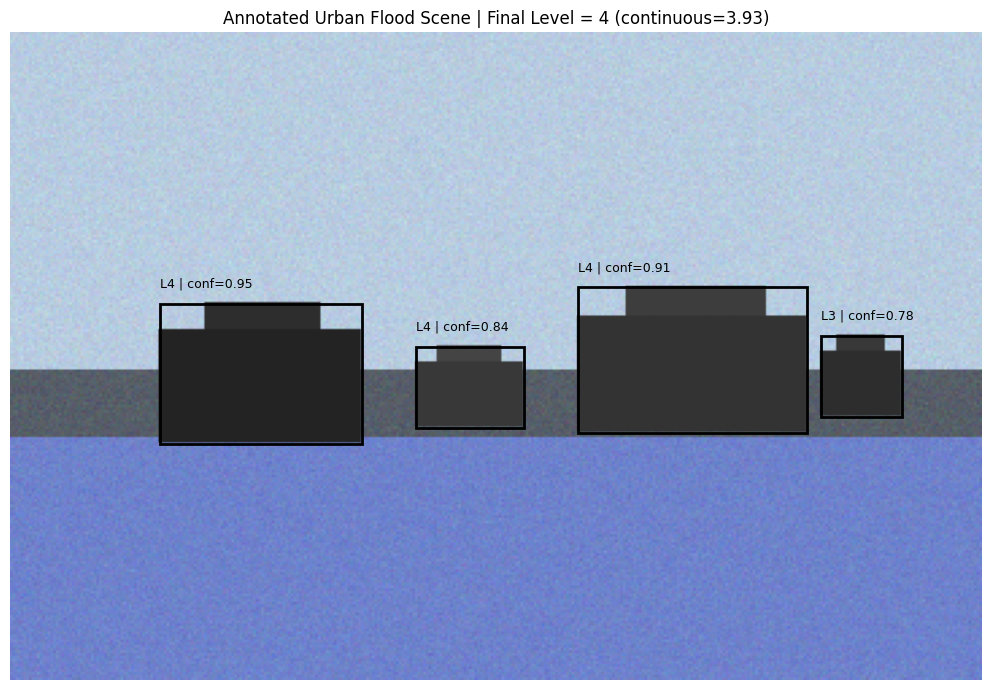

In [16]:

# Annotated visualization

fig, ax = plt.subplots(figsize=(11, 7))
ax.imshow(scene)

for det, cls_row in zip(detections, classification_records):
    x1, y1, x2, y2, conf, cls = det
    level = cls_row["predicted_level"]
    label = f"L{level} | conf={conf:.2f}"

    ax.add_patch(Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, linewidth=2))
    ax.text(x1, max(y1 - 6, 6), label, fontsize=9)

ax.set_title(f"Annotated Urban Flood Scene | Final Level = {final_level_discrete} (continuous={final_level_continuous:.2f})")
ax.axis("off")
plt.tight_layout()
plt.show()


In [17]:

# Final structured results table

final_results = classification_df.merge(
    aggregation_df[["crop_id", "expanded_area", "weight_conf_x_area"]],
    on="crop_id",
    how="left"
)

final_results


,crop_id,confidence,estimated_water_ratio,predicted_level,expanded_area,weight_conf_x_area
0,1,0.95,0.592,4,12555,11927.25
1,2,0.91,0.563,4,14841,13505.31
2,3,0.84,0.469,4,3888,3265.92
3,4,0.78,0.380,3,2916,2274.48



## How This Connects to the Full Research Workflow

The full project pipeline adds more advanced components such as:
- real detector inference using YOLO-World
- super-resolution enhancement using EDSR ×4
- trained ResNet-based flood-level classifier
- annotated image export
- CSV logging with timestamps and filenames

This notebook teaches the **logic and structure** of the pipeline in a simplified and reproducible way.


In [18]:

# Example research-style placeholders for a full implementation

# from ultralytics import YOLO
# detector = YOLO("yolov8_world.pt")

# results = detector("urban_flood_image.jpg")
# for r in results:
#     print(r)

# Example classifier prediction placeholder:
# flood_level = classifier.predict(processed_crop)

# Example CSV logging placeholder:
# final_results.to_csv(OUTPUT_DIR / "week06_prediction_log.csv", index=False)



## Mini Exercise

Answer the following in your own words:

1. Why might small crops need enhancement before classification?
2. Why is aggregation better than relying on a single crop?
3. What does confidence × area weighting try to capture?

Write your responses below.


In [19]:

# Write your Week 6 mini exercise responses here

# 1.
# 2.
# 3.



## Weekly Assignment

Choose one of the following:

### Option A
Write a short explanation of the full Week 6 pipeline:
- vehicle detections
- crop expansion
- enhancement logic
- flood-level classification
- weighted aggregation
- final scene-level output

### Option B
Modify one part of the notebook:
- change the crop expansion factor
- change the enhancement threshold
- change the water-ratio-to-level mapping

Then explain how your change affected the final flood-level result.


In [20]:

# Week 6 assignment response area

pipeline_explanation = ""
modification_notes = ""

print("Pipeline Explanation:", pipeline_explanation)
print("Modification Notes:", modification_notes)


Pipeline Explanation: 
Modification Notes: 



## Key Takeaway

The main lesson from Week 6 is:

> **Urban flood intelligence is strongest when multiple visual cues are processed as a structured pipeline rather than as isolated predictions.**

Detection, cropping, enhancement, classification, and aggregation each contribute to the final result. This is what turns a complex street scene into a usable flood severity estimate.



## Suggested Extensions

Later versions of this notebook can be expanded with:
- real urban flood imagery
- a trained classifier instead of rule-based simulation
- super-resolution comparison before and after enhancement
- CSV output saving
- confidence threshold experiments
- severity overlays with color-coded labels
- comparison between weighted and unweighted aggregation

This keeps the notebook beginner-friendly while preserving the structure of a real research workflow.
